# AI Club Recruitement task - Gayatri

# Data Preparation

Importing required machine learning architecture

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

from xgboost import XGBRegressor

Preprocessing the power demand data(converting datetime,resampling to hourly,duplicate handle,interpolating)

In [116]:
demand = pd.read_excel("/content/PGCB_date_power_demand.xlsx")

# Convert datetime
demand['datetime'] = pd.to_datetime(demand['datetime'])

# Sort properly
demand = demand.sort_values('datetime')

# Drop duplicates
demand = demand.drop_duplicates('datetime')

# Drop remarks column
demand = demand.drop(columns=['remarks'])

# Convert all numeric columns
for col in demand.columns:
    if col != 'datetime':
        demand[col] = pd.to_numeric(demand[col], errors='coerce')

# Set index
demand = demand.set_index('datetime')

# Resample to hourly
demand = demand.resample('H').mean()

# Interpolate missing values
demand = demand.interpolate()

/tmp/ipykernel_12159/2255628285.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  demand = demand.resample('H').mean()


Dropping columns which have more NaNs than actual data

In [117]:
# Drop columns with >50% missing
threshold = 0.5
demand = demand.loc[:, demand.isna().mean() < threshold]

Combining gas,liquid fuel,coal and hydro to get a total so that model trained with one number(total) instead of dealing with four different numbers which signify clean energy consumption.

In [118]:
demand['total_generation_components'] = (
    demand[['gas', 'liquid_fuel', 'coal', 'hydro']]
    .sum(axis=1)
)

Outlier detection & handling

In [119]:
rolling_median = demand['demand_mw'].shift(1).rolling(24).median()
residual = demand['demand_mw'] - rolling_median

threshold = 3 * residual.std()
outliers = np.abs(residual) > threshold

demand.loc[outliers, 'demand_mw'] = rolling_median[outliers]

In [120]:
print(demand.head())
print(demand.dtypes)


                     generation_mw  demand_mw  load_shedding  gas  \
datetime                                                            
2015-04-19 00:00:00         4821.0     4821.0            0.0  0.0   
2015-04-19 01:00:00         3612.0     3612.0            0.0  0.0   
2015-04-19 02:00:00         3727.0     3727.0            0.0  0.0   
2015-04-19 03:00:00         3632.0     3632.0            0.0  0.0   
2015-04-19 04:00:00         3641.0     3641.0            0.0  0.0   

                     liquid_fuel  coal  hydro  solar  india_bheramara_hvdc  \
datetime                                                                     
2015-04-19 00:00:00          0.0   0.0    0.0    NaN                   0.0   
2015-04-19 01:00:00          0.0   0.0    0.0    NaN                   0.0   
2015-04-19 02:00:00          0.0   0.0    0.0    NaN                   0.0   
2015-04-19 03:00:00          0.0   0.0    0.0    NaN                   0.0   
2015-04-19 04:00:00          0.0   0.0    0.0   

After all this processes, Nan will get generated,so they are replaced by zeros

In [121]:
demand = demand.fillna(0)

Weather:
Converted datetime,
Hourly data,
Renamed columns

In [122]:
weather = pd.read_excel("/content/Copy of weather_data.xlsx")

# If extra header rows exist → fix them
weather = weather.rename(columns=lambda x: str(x).strip())

# Rename time column
weather = weather.rename(columns={
    'time': 'datetime'
})

# Convert datetime
weather['datetime'] = pd.to_datetime(weather['datetime'])

# Sort
weather = weather.sort_values('datetime')

# Set index
weather = weather.set_index('datetime')

# Clean column names
weather.columns = [col.replace(' ', '_')
                       .replace('(', '')
                       .replace(')', '')
                       .replace('°', '')
                       .replace('%', '')
                       .replace('/', '_')
                  for col in weather.columns]

# Convert all to numeric
weather = weather.apply(pd.to_numeric, errors='coerce')

# Resample hourly
weather = weather.resample('H').mean().interpolate()

/tmp/ipykernel_12159/2647260138.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  weather = weather.resample('H').mean().interpolate()


Merging demand and weather

In [123]:
data = demand.merge(weather, left_index=True, right_index=True, how='left')

# Fill missing weather values
data = data.fillna(method='ffill')


/tmp/ipykernel_12159/315241036.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


In [124]:
print(data.isna().sum().sort_values(ascending=False).head())

generation_mw    0
demand_mw        0
load_shedding    0
gas              0
liquid_fuel      0
dtype: int64


Economics data preprocessing

In [128]:
econ = pd.read_csv("economic_full_1.csv")

# keep only one country (assuming X is your country)
econ = econ[econ['Country Name'] == 'X']

# drop non-year columns
econ = econ.drop(columns=['Country Name', 'Indicator Name', 'Indicator Code'])

# transpose → years become rows
econ = econ.T
econ.index.name = 'year'
econ = econ.reset_index()

# convert year to int
econ['year'] = econ['year'].astype(int)

# convert values to numeric
econ = econ.apply(pd.to_numeric, errors='coerce')

# aggregate indicators (simple mean)
econ['econ_index'] = econ.drop(columns=['year']).mean(axis=1)

econ = econ[['year', 'econ_index']]

#FEATURE ENGINEERING

Time based Feature

Based on year column,merging of data

In [129]:
data['year'] = data.index.year

data = data.reset_index()
data = data.merge(econ, on='year', how='left')
data = data.set_index('datetime')

data = data.fillna(method='ffill')

/tmp/ipykernel_12159/3897597388.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


In [130]:
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month
data['is_weekend'] = (data['dayofweek'] >= 5).astype(int)

Cyclical features

In [132]:
data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)

Lag features(memory related)

In [133]:
data['lag_1'] = data['demand_mw'].shift(1)
data['lag_2'] = data['demand_mw'].shift(2)
data['lag_24'] = data['demand_mw'].shift(24)
data['lag_168'] = data['demand_mw'].shift(168)  # weekly pattern

Rolling stats features

In [134]:
data['rolling_mean_24'] = data['demand_mw'].shift(1).rolling(24).mean()
data['rolling_std_24'] = data['demand_mw'].shift(1).rolling(24).std()

Define Target

In [135]:
data['target'] = data['demand_mw'].shift(-1)

In [136]:
data = data.dropna()

# TRAIN TEST SPLIT

In [137]:
split_date = "2023-01-01"

train = data[data.index < split_date]
test = data[data.index >= split_date]

X_train = train.drop('target', axis=1)
y_train = train['target']

X_test = test.drop('target', axis=1)
y_test = test['target']

model

In [138]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

MAPE Calculation

In [139]:
preds = model.predict(X_test)

# Filter out instances where y_test is 0 to avoid division by zero/near-zero issues in MAPE
non_zero_y_test_indices = y_test[y_test != 0].index
filtered_y_test = y_test.loc[non_zero_y_test_indices]
filtered_preds = pd.Series(preds, index=X_test.index).loc[non_zero_y_test_indices]

# Recalculate MAPE with filtered values
mape = np.mean(np.abs((filtered_y_test - filtered_preds) / filtered_y_test))

print("Final MAPE (excluding zero demand):", mape)

Final MAPE (excluding zero demand): 0.027462996289870818


# *FEATURE IMPORTANCE*

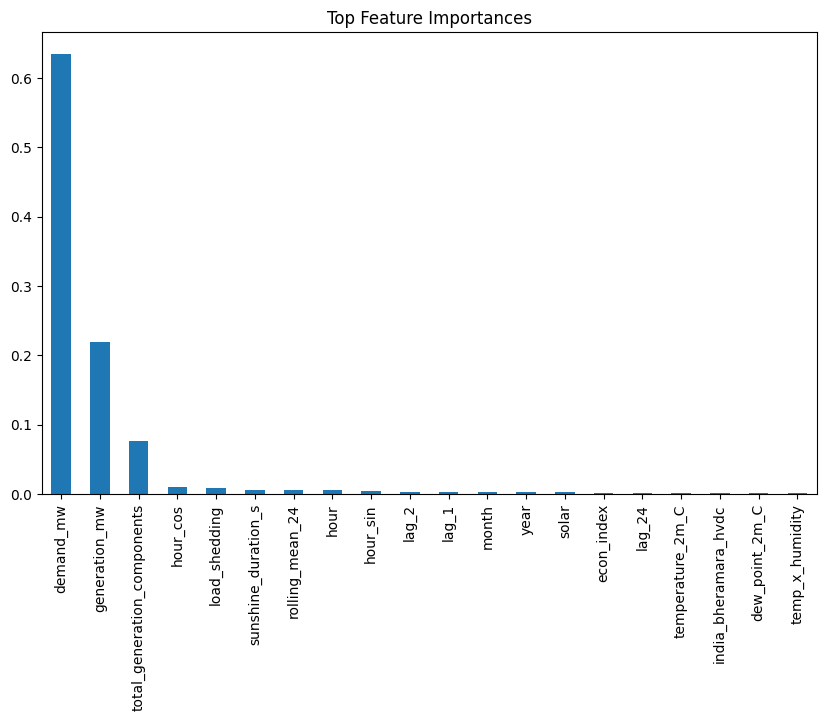

In [141]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(20).plot(kind='bar')
plt.title("Top Feature Importances")
plt.show()

# *PREDICTION PLOT*

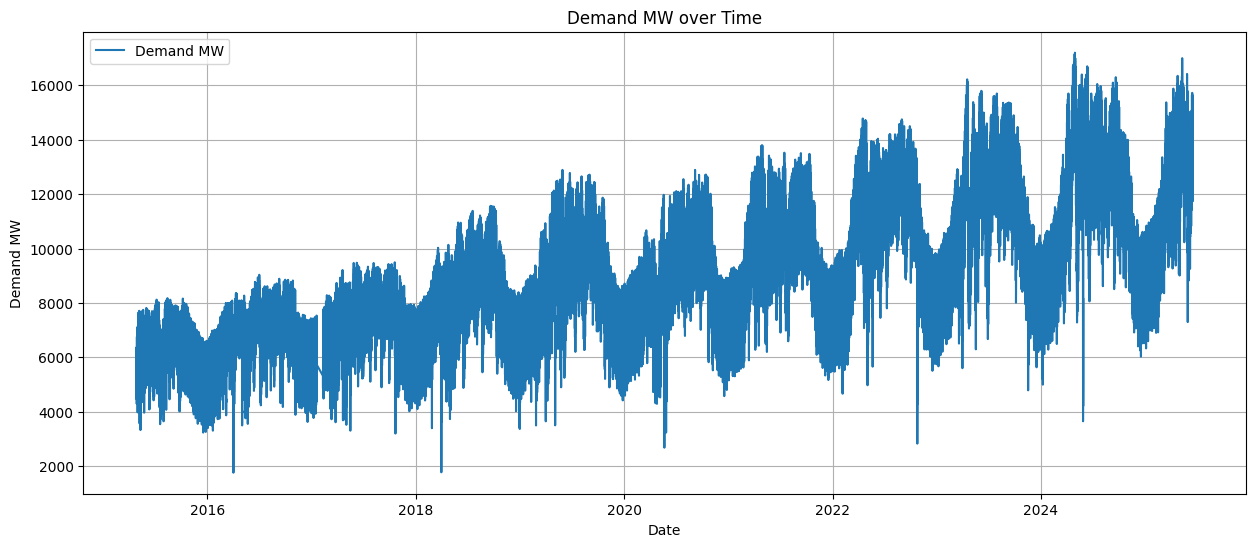

Number of zero demand_mw values: 0
Percentage of zero demand_mw values: 0.00%
Number of NaN demand_mw values: 0


In [140]:
plt.figure(figsize=(15, 6))
plt.plot(data.index, data['demand_mw'], label='Demand MW')
plt.title('Demand MW over Time')
plt.xlabel('Date')
plt.ylabel('Demand MW')
plt.grid(True)
plt.legend()
plt.show()

print(f"Number of zero demand_mw values: {(data['demand_mw'] == 0).sum()}")
print(f"Percentage of zero demand_mw values: {((data['demand_mw'] == 0).sum() / len(data['demand_mw'])):.2%}")

# Also check for NaNs just in case after final dropna, although dropna should remove them
print(f"Number of NaN demand_mw values: {data['demand_mw'].isnull().sum()}")

In [ ]:
print(demand.head())
print(weather.head())
print(econ.head())

print(demand.columns)
print(weather.columns)
print(econ.columns)

print(data.shape)
print(data.index.min(), data.index.max())